In [2]:
# 包文件路径配置
import os
import sys

current_dir = os.getcwd()
root_path = os.path.dirname(current_dir)
sys.path.append(root_path)
print("包环境路径导入：", root_path)


包环境路径导入： d:\PersonalFiles\大论文\code\AFTC


说明：
1. 环境的故障参数配置在`configs/params.json`中，具体是：
```json
    "simulation": {
        "fault_mode": 0,
        "fault_params": [0],
        "fault_start_time": 50,
        "fault_end_time": 100,
        "gyro_fault_idx": 1,
        "flywheel_fault_idx": 1
    }
```
    其中，故障参数相关说明见`params.json`中的`comments`字段：
```json
    "comments": {
        "0": "无故障 <0.0>",
        "1": "陀螺间歇故障 <f1>",
        "2": "陀螺缓变故障 <lambda_s, k_s>",
        "3": "陀螺乘性故障 <lambda_m>",
        "4": "反作用轮部分失效故障 <e>",
        "5": "反作用轮偏置故障 <b>",
        "6": "反作用轮综合故障 <e, b>"
    }   
```
注意：
1. Res-TD3算法用于处理反作用轮故障，配置故障参数时，应选择反作用轮相关故障类型。


INFO:src.satellite:卫星环境已经初始化，无需再次初始化
INFO:src.satellite:quat init: [[0.34196962]
 [0.21516679]
 [0.43402233]
 [0.80522335]]
INFO:src.satellite:omega init: [[-0.05910955]
 [ 0.07562349]
 [-0.09452248]]
INFO:src.satellite:q desired init: [[4.70924371e-01]
 [8.13430360e-01]
 [1.29158386e-04]
 [3.41410705e-01]]
INFO:src.satellite:fault mode: 0


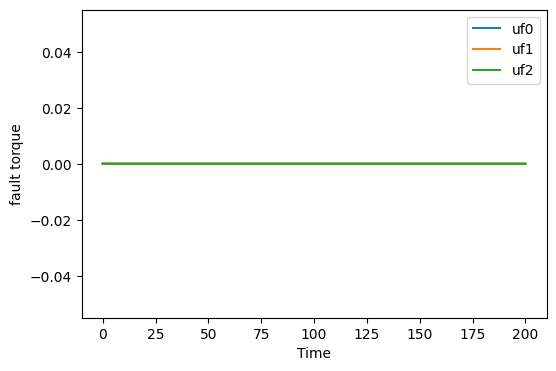

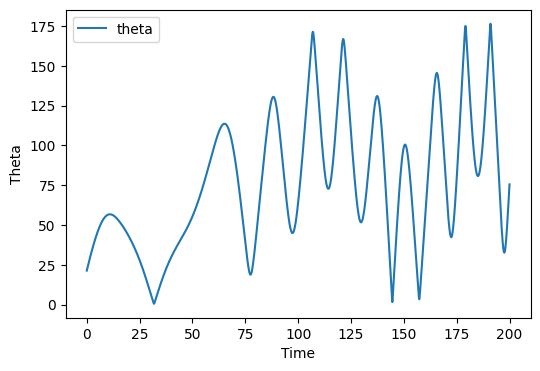

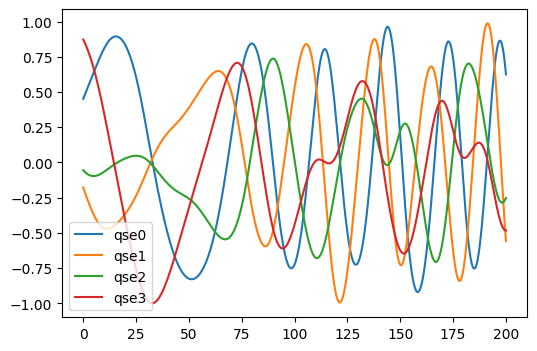

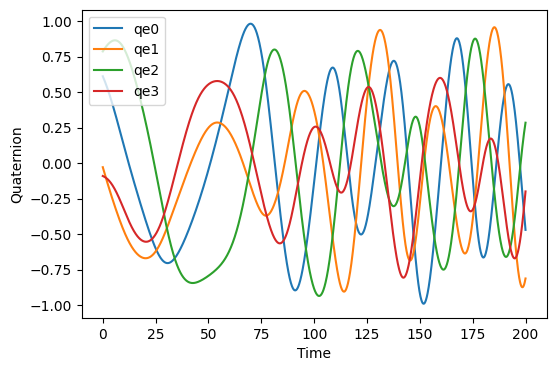

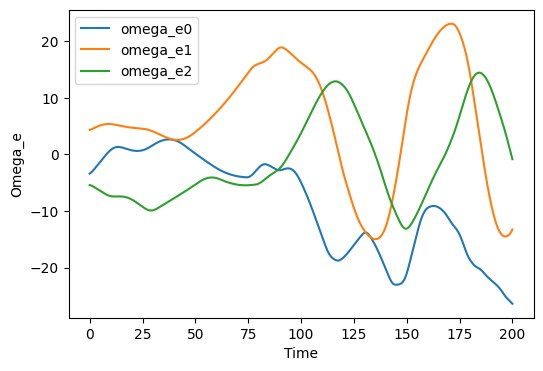

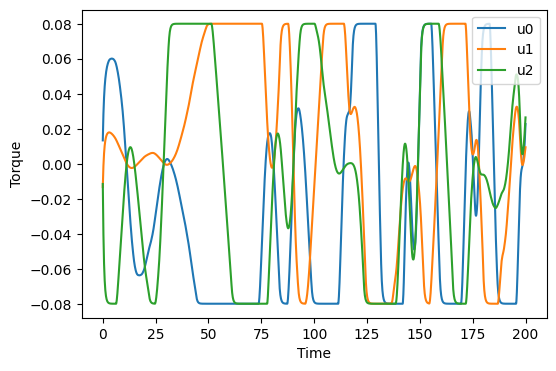

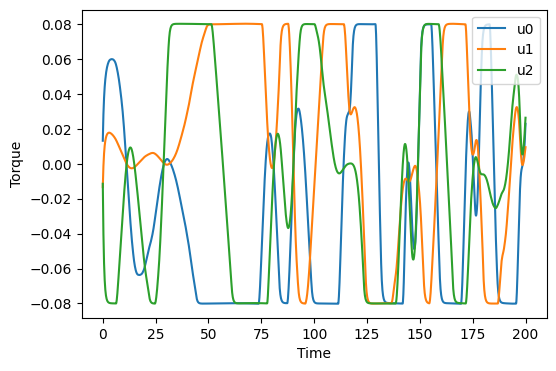

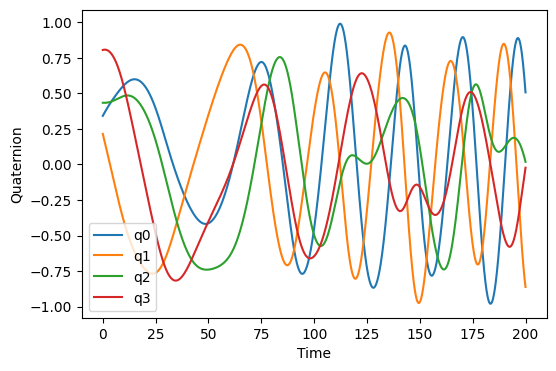

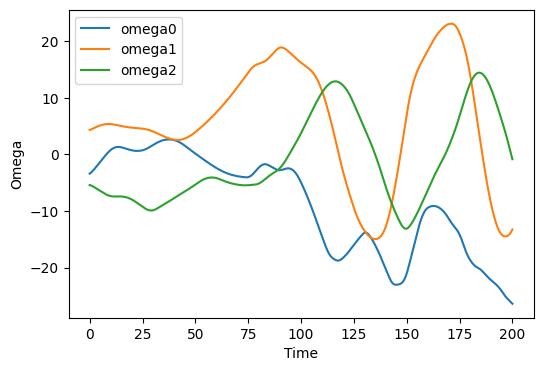

reward:  -38289.508457489166


In [4]:
# 验证TD3算法模型
import warnings
warnings.filterwarnings("ignore")

import torch
import pandas as pd

from configs.config import EnvConfig
from src.satellite import *
from src.pid import *
import src.td3 as td3


def eval_policy(policy_model_path:str, policy_hidden_size:List[int], env_name:str, seed:int, save_dir:Optional[str]=None, is_plot:bool=False):
    env_config = EnvConfig()
    env_config.reload()
    
    # 初始化环境
    if env_name == "Satellite":
        eval_env = Satellite(env_config)
    elif env_name == "FaultSatellite":
        eval_env = FaultSatellite(env_config)
    elif env_name == "SunPointSatellite":
        eval_env = SunPointSatellite(env_config)
    elif env_name == "SunPointFaultSatellite":
        eval_env = SunPointFaultSatellite(env_config)
    else:
        raise ValueError("Invalid env name")
    
    # 随机种子
    eval_env.seed(seed)

    # 加载控制模型
    state_dim = eval_env.observation_space.shape[0]
    state_dim += td3.STATE_APPEND_NUM
    action_dim = eval_env.action_space.shape[0]
    max_action = float(eval_env.action_space.high[0])
    actor = td3.Actor(state_dim, action_dim, max_action, policy_hidden_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if policy_model_path!= "":
        print("load model: ", policy_model_path)
        actor.load_state_dict(torch.load(f"../models/{policy_model_path}_actor", map_location=device))

    pid = PDController(dt=eval_env.ts)

    # 初始化变量
    rewards = []
    states = []
    state, done = eval_env.reset(), False
    state = np.concatenate((state, np.zeros(td3.STATE_APPEND_NUM)))

    while not done:
        agent_action = actor(torch.tensor(state, dtype=torch.float32).unsqueeze(0)).cpu().detach().numpy().flatten()
        pid.update(*agent_action)
        qev = state[1:4]
        omegae = state[4:7]
        action = pid.compute(qev, omegae)

        next_state, reward, done, _ = eval_env.step(action.reshape(-1, 1))
        state = next_state

        states.append(state)
        rewards.append(reward)

    states = np.array(states)
    rewards = np.array(rewards)
    if hasattr(eval_env, 'theta_buffer'):
        angles = np.array(eval_env.theta_buffer)
    else:
        angles = np.zeros_like(rewards)
    actions = np.array(eval_env.u_buffer)

    min_length = min(len(states), len(angles), len(actions), len(rewards))
    states = states[:min_length]
    angles = angles[:min_length]
    actions = actions[:min_length]
    rewards = rewards[:min_length]

    if save_dir and save_dir != "":
        if save_dir and not os.path.exists(save_dir):
            os.mkdir(save_dir)
        df = pd.DataFrame(states, columns=[f'state_{i}' for i in range(len(states[0]))])
        df_uc = pd.DataFrame(actions, columns=[f'u_{i}' for i in range(len(actions[0]))])
        df = pd.concat([df, df_uc], axis=1)
        df["angle"] = angles
        df['reward'] = rewards

        if not hasattr(eval_env, "fault_mode"):
            fault_mode = 0
        else:
            fault_mode = eval_env.fault_mode

        df.to_csv(f"{save_dir}/eval_{env_name}_{fault_mode}.csv", index=False)

    if is_plot:
        eval_env.plot()

    return np.sum(rewards)

# 验证
seed = 1
env_name = "SunPointFaultSatellite"
model_path = os.path.join(root_path, "models")
policy_model_path = ""
policy_hidden_size = [400, 300]

save_dir = ""

reward = eval_policy(policy_model_path, policy_hidden_size, env_name, seed, save_dir=save_dir, is_plot=True)
print("reward: ", reward)